# Checking Joined Data

In [1]:
import pandas as pd

df = pd.read_parquet("../data/processed/Amazon_Fashion_joined_reviews.parquet")

df.head()

,rating,review_title,review_text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_title,main_category,average_rating,rating_number,features,description,price,store,categories,details
0,5.0,Work great!!,"Took on an 11hr flight, no swelling of legs a...",B0741RGMWY,B07SB2892S,AEKQTUDQUVPC4AGXHDZRUZ5O6SVA,1563397135357,0,True,RONNOX Women's 3-Pairs Bright Colored Calf Com...,AMAZON FASHION,4.3,3032,"[""Pull On closure"", ""Size Guide: \""S\"" fits ca...","[""Ronnox Calf Sleeves - Allowing Your Body to ...",17.99,RONNOX,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pac..."
1,5.0,"Soft, warm and cuddly inside and out!",This coat is ridiculously soft and cuddly. Hug...,B00P6856G4,B00P6856G4,AEFFPBIBMATA7ZIUGX4BBMNWPSHQ,1546565318022,2,True,EGALAXY Baby Girls Faux Fur Leopard Hoodies Co...,AMAZON FASHION,4.0,4,[],[],NaN,EGALAXY,[],"{""Package Dimensions"": ""18.8 x 17 x 4.8 inches..."
2,5.0,Love it. Very comfy and fits,Love it. Very comfy and fits great,B06Y5W9CWR,B06Y5W9CWR,AE44NZAHAB2J4IB7MZCSOQJLNDQQ,1496632783000,0,True,Huiyuzhi Womens Sleeveless Racerback Floral Pr...,AMAZON FASHION,3.5,2,[],[],NaN,Huiyuzhi,[],"{""Package Dimensions"": ""9.92 x 8.9 x 1.85 inch..."
3,4.0,Nice fit and comfortable too.,"These polos are cute, comfortable, easy to pul...",B07HRTNRC5,B07HRTNRC5,AFQ7WYW4KSH4VI5OVXCP2GV6PBRA,1579590676819,0,True,NIKE Dri Fit Sleeveless Stripe OLC Golf Polo 2...,AMAZON FASHION,4.8,8,"[""100% Polyester"", ""Button closure"", ""Machine ...",[],19.97,Nike,[],"{""Product Dimensions"": ""15.5 x 12 x 2 inches; ..."
4,3.0,SIZING,"Great Shoe Design. Runs Short In Sizing, Sadly...",B015WY1ZYI,B015WXZSZ6,AETE7Y3DZT6BLMWA6U27ADJDZ4LA,1517382954312,0,True,Bandolino Women's BERTA Platform Pump,AMAZON FASHION,4.0,182,"[""Rubber sole""]","[""A modest platform heightens this go-to dress...",59.95,Bandolino,[],"{""Item Weight"": ""15 Ounces"", ""Item model numbe..."


In [2]:
df.shape

(20000, 19)

In [3]:
df.columns.tolist()

['rating',
 'review_title',
 'review_text',
 'asin',
 'parent_asin',
 'user_id',
 'timestamp',
 'helpful_vote',
 'verified_purchase',
 'product_title',
 'main_category',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'store',
 'categories',
 'details']

In [4]:
df[
    [
        "product_title",
        "review_title",
        "review_text",
        "rating",
        "price",
        "store"
    ]
].head(10)

,product_title,review_title,review_text,rating,price,store
0,RONNOX Women's 3-Pairs Bright Colored Calf Com...,Work great!!,"Took on an 11hr flight, no swelling of legs a...",5.0,17.99,RONNOX
1,EGALAXY Baby Girls Faux Fur Leopard Hoodies Co...,"Soft, warm and cuddly inside and out!",This coat is ridiculously soft and cuddly. Hug...,5.0,NaN,EGALAXY
2,Huiyuzhi Womens Sleeveless Racerback Floral Pr...,Love it. Very comfy and fits,Love it. Very comfy and fits great,5.0,NaN,Huiyuzhi
3,NIKE Dri Fit Sleeveless Stripe OLC Golf Polo 2...,Nice fit and comfortable too.,"These polos are cute, comfortable, easy to pul...",4.0,19.97,Nike
4,Bandolino Women's BERTA Platform Pump,SIZING,"Great Shoe Design. Runs Short In Sizing, Sadly...",3.0,59.95,Bandolino
5,Allmygold Long Stem Dipped 24K Gold Trim Genui...,Great gift,Gave this to someone as a gift and she loved it,5.0,99.00,Allmygold
6,SUEANI Women's Waffle Knit Tunic Blouse Loose ...,"Comfy textured fabric, nice fit",The waffle knit fabric has a neat texture and ...,5.0,NaN,SUEANI
7,NINEXIS Women's Round Neck Short Sleeve Dolman...,"excellent is all respects, size is spot on",[[VIDEOID:a554b26f94d088cb9114fd7357d208f2]] ★...,5.0,NaN,NINEXIS
8,Reebok Men's Lightweight Workout Gym & Running...,Husband loves these shorts,I bought a size large. they are true to size....,5.0,NaN,Reebok
9,icyzone Workout Tank Tops for Women - Running ...,Best work out shirt ever,Wore this in The Bix 7 2019 and loved it!!,5.0,14.99,icyzone


# Check for missing values across all columns

In [5]:
empty_string_summary = pd.DataFrame({
    "empty_string_count": (df.astype(str).apply(lambda col: col.str.strip().eq("").sum())),
})

empty_string_summary["empty_string_pct"] = (
    empty_string_summary["empty_string_count"] / len(df) * 100
).round(2)

empty_string_summary = empty_string_summary.sort_values("empty_string_pct", ascending=False)

empty_string_summary[empty_string_summary["empty_string_count"] > 0]

,empty_string_count,empty_string_pct
review_text,3,0.02
product_title,2,0.01


In [6]:
fake_missing_values = ["None", "none", "nan", "NaN", "null", "NULL", "[]", "{}"]

fake_missing_summary = {}

for col in df.columns:
    fake_missing_summary[col] = df[col].astype(str).isin(fake_missing_values).sum()

fake_missing_summary = pd.DataFrame.from_dict(
    fake_missing_summary,
    orient="index",
    columns=["fake_missing_count"]
)

fake_missing_summary["fake_missing_pct"] = (
    fake_missing_summary["fake_missing_count"] / len(df) * 100
).round(2)

fake_missing_summary = fake_missing_summary.sort_values(
    "fake_missing_pct",
    ascending=False
)

fake_missing_summary[fake_missing_summary["fake_missing_count"] > 0]

,fake_missing_count,fake_missing_pct
categories,20000,100.00
description,17911,89.56
features,7783,38.92
details,572,2.86
review_title,5,0.02
review_text,1,0.00
store,1,0.00


In [7]:
missing_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "empty_string_count": df.astype(str).apply(lambda col: col.str.strip().eq("").sum()),
    "fake_missing_count": df.astype(str).apply(
        lambda col: col.isin(["None", "none", "nan", "NaN", "null", "NULL", "[]", "{}"]).sum()
    ),
    "unique_count": df.nunique(dropna=True)
})

missing_report["empty_string_pct"] = (
    missing_report["empty_string_count"] / len(df) * 100
).round(2)

missing_report["fake_missing_pct"] = (
    missing_report["fake_missing_count"] / len(df) * 100
).round(2)

missing_report = missing_report.sort_values(
    ["missing_pct", "empty_string_pct", "fake_missing_pct"],
    ascending=False
)

missing_report

,dtype,missing_count,missing_pct,empty_string_count,fake_missing_count,unique_count,empty_string_pct,fake_missing_pct
price,float64,17258,86.29,0,0,619,0.00,0.00
store,str,465,2.33,0,1,8983,0.00,0.00
review_text,str,0,0.00,3,1,19360,0.02,0.00
product_title,str,0,0.00,2,0,17444,0.01,0.00
categories,str,0,0.00,0,20000,1,0.00,100.00
description,str,0,0.00,0,17911,1478,0.00,89.56
features,str,0,0.00,0,7783,4161,0.00,38.92
details,str,0,0.00,0,572,16867,0.00,2.86
review_title,str,0,0.00,0,5,14516,0.00,0.02
rating,float64,0,0.00,0,0,5,0.00,0.00


In [8]:
df["categories"].value_counts()

categories
[]    20000
Name: count, dtype: int64

In [9]:
import json
from pathlib import Path
from collections import Counter

FULL_META_PATH = Path.cwd().parent / "data" / "raw" / "Amazon_Fashion.jsonl"
category_values = Counter()

with open(FULL_META_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):

        row = json.loads(line)
        categories = row.get("categories")

        category_values[str(categories)] += 1

category_values.most_common(10)

# Categories are straight up just empty --> remember to remove it

[('None', 2500939)]

# Looking at Features and Details

In [11]:
df[
    ["product_title", "features", "details"]
].sample(10, random_state=42)

,product_title,features,details
10650,The Cramps 'Off The Bone' (Green) T-Shirt (ext...,"[""Pull On closure"", ""Machine Wash""]","{""Product Dimensions"": ""9.45 x 8.66 x 0.79 inc..."
2041,Michael Michael Kors Solid Peplum Knit Top Tru...,"[""Pull On closure""]","{""Package Dimensions"": ""11.65 x 6.75 x 2.15 in..."
8668,NIASHOT Women Basic T Shirt Round Neck Oversiz...,[],"{""Package Dimensions"": ""13.5 x 10 x 0.5 inches..."
1114,"3C-LIFE Band 42mm Women for Apple iWatch,Genui...","[""Buckle closure"", ""Compatible with All Apple ...","{""Is Discontinued By Manufacturer"": ""No"", ""Pro..."
13902,BSC007 Women's Plus Size Boho Maxi Dress Tie D...,"[""Wrap closure""]","{""Package Dimensions"": ""13.43 x 9.25 x 1.65 in..."
11963,EW David T-Shirts Women TV Show Fans Shirt Ros...,"[""Cotton Blend"", ""Pull On closure"", ""Tumble dr...","{""Date First Available"": ""March 18, 2021""}"
11072,Travelon Anti-Theft Crossbody and RFID ID Pouc...,[],"{""Product Dimensions"": ""4 x 14 x 10.25 inches;..."
3002,ouslee Women's V Neck Tank Tops Knit Vest Tops...,"[""Button closure""]","{""Package Dimensions"": ""12.06 x 9.81 x 1.77 in..."
19771,CARGFM Women's Seamless Yoga Leggings High Wai...,"[""Drawstring closure""]","{""Package Dimensions"": ""9.96 x 9.17 x 2.4 inch..."
8115,Dearlovers Women Retro African Print High Wais...,"[""Zipper closure""]","{""Package Dimensions"": ""13.5 x 9.69 x 1.18 inc..."


In [12]:
def parse_json_like(value):
    if pd.isna(value):
        return None
    
    if isinstance(value, (dict, list)):
        return value
    
    value = str(value).strip()
    
    if value in ["", "None", "none", "nan", "NaN", "null", "NULL", "[]", "{}"]:
        return None
    
    try:
        return json.loads(value)
    except Exception:
        return None

In [13]:
detail_key_counter = Counter()

for value in df["details"]:
    parsed = parse_json_like(value)
    
    if isinstance(parsed, dict):
        detail_key_counter.update(parsed.keys())

detail_key_counter.most_common(30)

[('Date First Available', 19314),
 ('Package Dimensions', 12464),
 ('Item model number', 9574),
 ('Is Discontinued By Manufacturer', 7842),
 ('Department', 4481),
 ('Product Dimensions', 4273),
 ('Manufacturer', 2904),
 ('Brand', 1505),
 ('Material', 899),
 ('Age Range (Description)', 797),
 ('Color', 684),
 ('Style', 661),
 ('Item Weight', 581),
 ('Size', 367),
 ('Closure Type', 366),
 ('Special Feature', 304),
 ('Pattern', 250),
 ('Shape', 216),
 ('Country of Origin', 180),
 ('Reusability', 173),
 ('Theme', 166),
 ('Unit Count', 147),
 ('Item Package Quantity', 127),
 ('Sport', 114),
 ('Number of Items', 112),
 ('Batteries', 108),
 ('Manufacturer recommended age', 94),
 ('Clasp Type', 90),
 ('Item Dimensions LxWxH', 86),
 ('Frame Material', 72)]

In [14]:
top_detail_keys = [key for key, count in detail_key_counter.most_common(10)]

for key in top_detail_keys:
    print("=" * 80)
    print(f"KEY: {key}")
    
    values = []
    
    for value in df["details"]:
        parsed = parse_json_like(value)
        
        if isinstance(parsed, dict) and key in parsed:
            values.append(parsed[key])
        
        if len(values) >= 10:
            break
    
    print(values)

KEY: Date First Available
['July 18, 2017', 'November 3, 2014', 'May 6, 2017', 'October 22, 2018', 'February 10, 2016', 'December 17, 2012', 'October 12, 2021', 'August 13, 2016', 'March 2, 2020', 'May 26, 2019']
KEY: Package Dimensions
['7.7 x 4.3 x 1.8 inches; 6.38 Ounces', '18.8 x 17 x 4.8 inches; 15.2 Ounces', '9.92 x 8.9 x 1.85 inches; 5.26 Ounces', '13.2 x 4.1 x 3.2 inches; 8 Ounces', '12.48 x 10.43 x 1.26 inches; 8.47 Ounces', '8.7 x 8.2 x 1.9 inches; 0.35 Ounces', '8.6 x 7.8 x 0.4 inches', '8.98 x 8.58 x 1.5 inches; 2.72 Ounces', '13.82 x 12.8 x 0.79 inches; 11.99 Ounces', '12.83 x 11.1 x 3.78 inches; 2.3 Pounds']
KEY: Item model number
['BERTA', 'AMG9342Z', 'SU2048-Dark green-L-FBA', 'REM201SH02B011', '1', '41088 (CON088) Black', 'TP-860-NEW', 'YSW5402-7403-0F-16', '230-15-10-003', 'US-SA-AJD-47470']
KEY: Is Discontinued By Manufacturer
['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No']
KEY: Department
['womens', 'Womens', 'Womens', 'womens', 'womens', 'Womens', 'boy

In [15]:
feature_examples = []

for value in df["features"]:
    parsed = parse_json_like(value)
    
    if isinstance(parsed, list) and len(parsed) > 0:
        feature_examples.append(parsed)
    
    if len(feature_examples) >= 10:
        break

feature_examples

[['Pull On closure',
  'Size Guide: "S" fits calf 10-12 inches. "M" fits calf 12-14 inches. "L" fits calf 14-16 inches. "XL" fits calf 16-18 inches. The above size guide is for calf circumference the length of the sleeve unstretched is approx: S, 11 inch. M, 12 inch. L, 13 inch. XL, 14 inch',
  '3 Pairs: Styles and colors as seen in the picture. Choose between colorful sporty patterns & colored solids',
  'Medium Compression: The solid styles have 16-20 mmHg Graduated Compression. The pattern styles have 12-14 mmHg Graduated Compression',
  'Compression improves blood flow, aids with circulation, and keeps your feet energized. Great for running, athletic activities, & for nursing or standing all day',
  'Helps in reducing swelling and aching in the legs. Great for pregnancy & flight travel or sitting long periods'],
 ['100% Polyester', 'Button closure', 'Machine Wash'],
 ['Rubber sole'],
 ['24k Gold Dipped Green Lacquered Genuine Rose',
  'Each rose measures 11-12 inches long and is pa

In [16]:
product_df = df.drop_duplicates("parent_asin").copy()

product_df["details_parsed"] = product_df["details"].apply(parse_json_like)
product_df["features_parsed"] = product_df["features"].apply(parse_json_like)

product_df["has_usable_details"] = product_df["details_parsed"].apply(
    lambda x: isinstance(x, dict) and len(x) > 0
)

product_df["has_usable_features"] = product_df["features_parsed"].apply(
    lambda x: isinstance(x, list) and len(x) > 0
)

print("Products:", len(product_df))
print("Products with usable details:", product_df["has_usable_details"].sum())
print("Products with usable features:", product_df["has_usable_features"].sum())

print("Details usable %:", round(product_df["has_usable_details"].mean() * 100, 2))
print("Features usable %:", round(product_df["has_usable_features"].mean() * 100, 2))

#A lot of dewtails are related to logistics or catalog info. However, it still have
# many useful metadata we can extract from

# Features is missing too foten so be careful on using it for modeling.
# However, it includes a lot of signals for sensory screening.

Products: 17693
Products with usable details: 17175
Products with usable features: 10550
Details usable %: 97.07
Features usable %: 59.63


# Conclusion on column variables

- categories is unusable and should be dropped.
- description and price are too missing
- details is highly available and partially useful.
- features is useful but missing in about 40% of products.
- review text is still the main evidence source.


# Rating Distribution

In [17]:
rating_counts = (
    df["rating"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_counts.columns = ["rating", "review_count"]

rating_counts["review_pct"] = (
    rating_counts["review_count"] / len(df) * 100
).round(2)

rating_counts

,rating,review_count,review_pct
0,1.0,1526,7.63
1,2.0,1264,6.32
2,3.0,2187,10.94
3,4.0,3793,18.96
4,5.0,11230,56.15


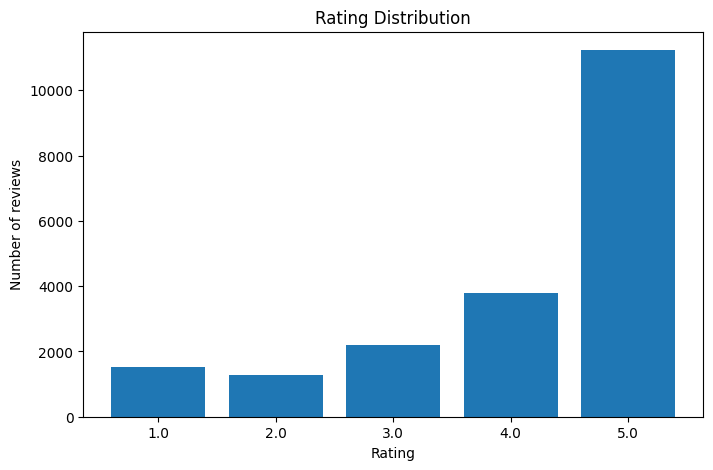

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(rating_counts["rating"].astype(str), rating_counts["review_count"])
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.title("Rating Distribution")
plt.show()

# Review Length

In [19]:
df["review_text_clean"] = df["review_text"].fillna("").astype(str)

df["review_char_length"] = df["review_text_clean"].str.len()

df["review_word_length"] = (
    df["review_text_clean"]
    .str.split()
    .apply(len)
)

df[["review_char_length", "review_word_length"]].describe()

,review_char_length,review_word_length
count,20000.000000,20000.000000
mean,246.219650,46.458050
std,311.599447,58.261323
min,0.000000,0.000000
25%,56.000000,10.000000
50%,143.000000,27.000000
75%,325.000000,62.000000
max,6287.000000,1228.000000


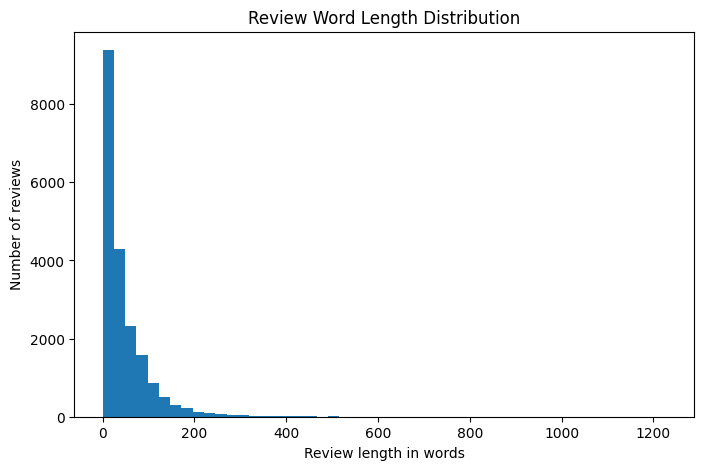

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["review_word_length"], bins=50)
plt.xlabel("Review length in words")
plt.ylabel("Number of reviews")
plt.title("Review Word Length Distribution")
plt.show()

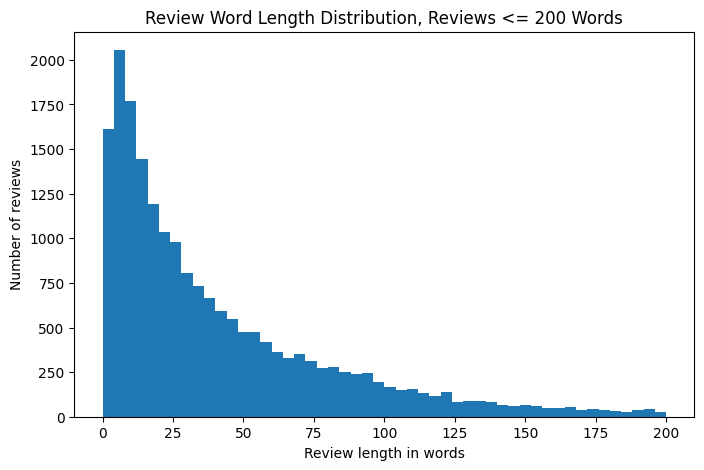

In [21]:
shorter_reviews = df[df["review_word_length"] <= 200]

plt.figure(figsize=(8, 5))
plt.hist(shorter_reviews["review_word_length"], bins=50)
plt.xlabel("Review length in words")
plt.ylabel("Number of reviews")
plt.title("Review Word Length Distribution, Reviews <= 200 Words")
plt.show()

In [23]:
df[df["review_word_length"] <= 3][
    ["product_title", "review_title", "review_text", "rating"]
].sample(20, random_state=42)

,product_title,review_title,review_text,rating
291,Game Face Bandana Face Protector Reusable Adju...,A++,Perfect,5.0
1146,925 Sterling Silver Christian Cross Religious ...,I'd buy it again,Nice,5.0
8763,"Cooling Skull Cap Helmet Liner for Men, Head B...",Works just fine,Works just fine,5.0
17439,Signature by Levi Strauss & Co. Women's Modern...,The perfect Jean!,Perfect!,5.0
2087,Knockaround Fast Lanes Polarized Sunglasses fo...,Nice shades,Nice shades,5.0
11592,Buxton Cabaret Hot Pink Hailey Super Wallet,Four Stars,Very nice,4.0
14043,Fashion Story Babydoll Glossy Lingerie One-pie...,way too small,way too small,3.0
11515,Intimate Portal Women's Allure Back Smoothing ...,One Star,Didn't like it,1.0
10843,Everrich Rhinestone Simulated Diamond Water Dr...,Two Stars,gawdy,2.0
16946,14k Gold Ball Earrings with Matching 14k Pushb...,Five Stars,Beautiful!,5.0


In [24]:
df[df["review_word_length"] >= 50][
    ["product_title", "review_title", "review_text", "rating"]
].sample(20, random_state=42)

,product_title,review_title,review_text,rating
4229,SAMPEEL Womens V Neck Pullover Sweatshirts Ove...,Soft warm long sleeve shirt,I’d like to say it feels more sweater like but...,5.0
7188,Leather Toiletry Bags for Travelling Men/Women...,100% hands down classy... Wow!!!,Wowza! Are you kidding me..?!! This is almost ...,5.0
10826,Ork Tree Summer Sandals for Women Flip Flops B...,So pretty,I love how unique these sandals are. They real...,5.0
2638,SKYDEER 3M Thinsulate Thermal Winter Work Glov...,Warm but big,I walk to work everyday & have tried dozens of...,4.0
9581,GLADDON MODA Women's Crossbody Bag Gray,"If you don't mind the clear windows, this is a...",I think this pleather snake skin purse is real...,5.0
3218,PenSee Mens Solid Bowtie Woven Self Tie Bow Ti...,"Microfiber self-tie bow tie, good weight, silk...",We are a self-tie bow tie family. I (the only ...,5.0
13469,Scriptural Rosary 2-CD Set,Listening & Praying the Rosary in the Spirit o...,This is a gem that has been around a long time...,5.0
1642,KOSY KOMFORT Mens Cotton 6-Pack Low Cut Ankle ...,Awesome socks,I’ve had socks by this company before. I love...,4.0
3643,LaRaso & Co Long Necklace and Earring Jewelry ...,Fun and cute!,My wife really likes these polished stone look...,5.0
9092,Boutique23 Women's Camisole-Neck Shift Dress w...,Cute dress,This is a cute dress. I liked it. I thought it...,4.0


In [25]:
# Number of reviews / product

In [26]:
reviews_per_product = (
    df.groupby("parent_asin")
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

reviews_per_product.head(20)

,parent_asin,review_count
17142,B09TXZHKLG,33
16847,B09KHSM7BB,25
16906,B09M6X79V9,24
17182,B09WJSHQFL,22
13308,B084RYPGXN,21
17049,B09QFJGKM5,18
9318,B07GKLQ5KV,16
8500,B07CQ84KLT,14
193,B0045H0L1W,13
17264,B0B12PBSTG,12


In [27]:
product_titles = df[["parent_asin", "product_title"]].drop_duplicates()

reviews_per_product_with_titles = reviews_per_product.merge(
    product_titles,
    on="parent_asin",
    how="left"
)

reviews_per_product_with_titles.head(20)

,parent_asin,review_count,product_title
0,B09TXZHKLG,33,Casio F91W-1 Classic Resin Strap Digital Sport...
1,B09KHSM7BB,25,Russell Athletic Men's Dri-Power Fleece Hoodie...
2,B09M6X79V9,24,NELEUS Women's 3 Pack Compression Base Layer D...
3,B09WJSHQFL,22,Nurse Mates Womens 12-14 MMGH Compression Calf...
4,B084RYPGXN,21,"Polishing Cloth for Silver, Gold, Brass & Most..."
5,B09QFJGKM5,18,Copper Fit Energy Unisex Easy-On/Easy-Off Knee...
6,B07GKLQ5KV,16,90 Degree By Reflex High Waist Squat Proof Tum...
7,B07CQ84KLT,14,LILBETTER Women V-Neck Polka Dot Print Spaghet...
8,B0045H0L1W,13,LED Finger Lights (40 pcs)
9,B0B12PBSTG,12,HEARTEK Noise Cancelling Headphones Kids Adult...


In [28]:
reviews_per_product["review_count"].describe()

count    17693.000000
mean         1.130391
std          0.704391
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         33.000000
Name: review_count, dtype: float64

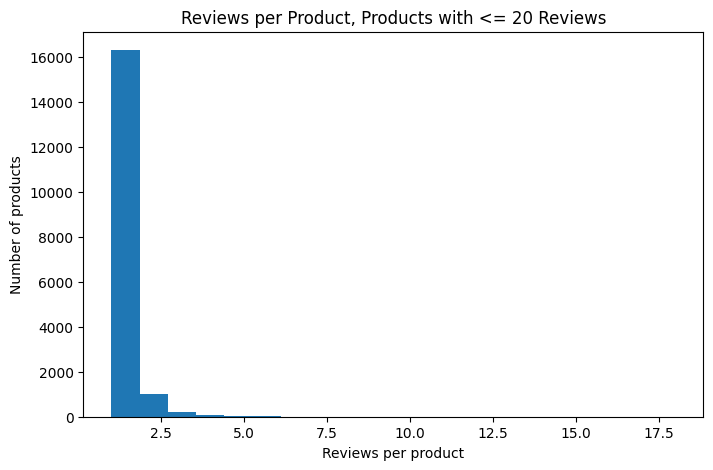

In [30]:
products_20_or_less = reviews_per_product[
    reviews_per_product["review_count"] <= 20
]

plt.figure(figsize=(8, 5))
plt.hist(products_20_or_less["review_count"], bins=20)
plt.xlabel("Reviews per product")
plt.ylabel("Number of products")
plt.title("Reviews per Product, Products with <= 20 Reviews")
plt.show()

In [31]:
eda_summary = {
    "total_reviews": len(df),
    "unique_products": df["parent_asin"].nunique(),
    "avg_reviews_per_product": round(len(df) / df["parent_asin"].nunique(), 2),
    "median_review_words": df["review_word_length"].median(),
    "mean_review_words": round(df["review_word_length"].mean(), 2),
    "pct_reviews_5_star": round((df["rating"].eq(5).mean() * 100), 2),
    "pct_reviews_4_or_5_star": round((df["rating"].isin([4, 5]).mean() * 100), 2),
    "pct_reviews_under_5_words": round((df["review_word_length"].lt(5).mean() * 100), 2),
}

eda_summary

{'total_reviews': 20000,
 'unique_products': 17693,
 'avg_reviews_per_product': 1.13,
 'median_review_words': np.float64(27.0),
 'mean_review_words': np.float64(46.46),
 'pct_reviews_5_star': np.float64(56.15),
 'pct_reviews_4_or_5_star': np.float64(75.11),
 'pct_reviews_under_5_words': np.float64(10.88)}

The initial EDA shows that the Amazon Fashion dataset is usable for review-level sensory-risk exploration, but not yet strong enough for final product-level ranking. The key review fields, including review_text, review_title, rating, and parent_asin, are complete, and the product metadata join worked correctly with no missing matched products. However, some metadata fields are not reliable: categories is entirely missing in the raw data, description is mostly empty, and price has high missingness, so these should not be used in the first version. The most useful metadata fields are details, which is available for about 97% of products, and features, which is useful when present but missing for around 40% of products.

The rating distribution is heavily positive, meaning sensory complaints should be searched across all reviews rather than only low-rated reviews. Review text length appears usable for keyword exploration, but the 20,000-row dev sample has a major limitation: most products only have one review, so product-level risk scores would be unstable at this stage. Overall, this sample is appropriate for EDA, debugging, and developing weak sensory-label rules, but final product scoring should wait until we use a larger sample or the full Amazon Fashion dataset.